# **EDA 2--Salaries in the Technology Sector in Latin America**

This analysis aims to examine salary patterns in the technology sector across Latin America by evaluating income levels, regional distribution, and work arrangements in order to better understand the dynamics of the regional labor market.

Table of Contents

1.  Main Objective
2.  Secondary Objectives
3.  Initial Exploration
4.  Data Preparation and Cleaning
5.  Analysis 1 – Salary Distribution in Latin America
6.  Analysis 2 – Professional Experience and Salary Level
7.  Analysis 3 – Professional Role and Salary level
8.  Analysis 4 - Work Arrangements and High Salaries
9.  Analysis 5 – Country of Origin and Salary Influence
10.  Final Conclusion
11. Insights

#Main Research Objective

To analyze salary levels in the technology sector within Latin American context.

#Secondary reserch objective

* To evaluate the relationship between professional experience and income level.
* To analyze the impact of work arrangements(remote, hybrid, in-person) on salary levels.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Initial data exploration

In [3]:
df= pd.read_csv('/content/drive/MyDrive/Datos/survey_results_public.csv')
#df.head()

In [4]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

In [5]:
cols = [
    "Country",
    "ConvertedCompYearly",
    "YearsCodePro",
    "Employment",
    "RemoteWork",
    "DevType"
]

df_latam_base = df[cols]
df_latam_base.head()

,Country,ConvertedCompYearly,YearsCodePro,Employment,RemoteWork,DevType
0,United States of America,NaN,NaN,"Employed, full-time",Remote,NaN
1,United Kingdom of Great Britain and Northern I...,NaN,17,"Employed, full-time",Remote,"Developer, full-stack"
2,United Kingdom of Great Britain and Northern I...,NaN,27,"Employed, full-time",Remote,Developer Experience
3,Canada,NaN,NaN,"Student, full-time",NaN,"Developer, full-stack"
4,Norway,NaN,NaN,"Student, full-time",NaN,"Developer, full-stack"


In [6]:
df_latam_base= df_latam_base[df_latam_base['Employment'].str.contains("Employed, full-time", na = False)]

### Filtering LATAM Countries

In this step, the dataset was filtered to include only countries from Latin America in order to focus the analysis on the regional technology job market.

In [7]:
latam_countries =[
    "Argentina", "Brazil", "Chile",
    "Colombia", "Mexico", "Peru",
    "Uruguay", "Costa Rica"
]

df_latam = df_latam_base[
    df_latam_base['Country'].isin(latam_countries)
    ]


In [8]:
df_latam['ConvertedCompYearly'].isna().sum()

np.int64(870)

#Handling missing values

This step examines missing values in the dataset and applies appropiate strategies to handle them before continuing the analysis.

In [9]:
#Se eliminan los nulos
df_latam = df_latam.dropna(subset=['ConvertedCompYearly'])

In [10]:
pd.reset_option("display.float_format")

In [11]:
df_latam.shape
df_latam['Country'].value_counts()

,count
Country,
Brazil,604
Mexico,150
Argentina,107
Colombia,84
Chile,44
Uruguay,31
Peru,23
Costa Rica,22


In [12]:
#Se eliminan los paises que no tienen una cantidad de datos relevantes
country_counts =df_latam['Country'].value_counts()
valid_countries =country_counts[country_counts>=30].index
df_latam = df_latam[df_latam['Country'].isin(valid_countries)]

In [13]:
#Se corrigen inconsistencias en la variable YearsCodePro, que contiene valores numéricos y texto.

df_latam['YearsCodePro'] = df_latam['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years':50
})
df_latam['YearsCodePro']=pd.to_numeric(df_latam['YearsCodePro'], errors='coerce'
)
df_latam= df_latam.dropna(subset=['YearsCodePro'])

In [14]:
df_latam['YearsCodePro'].describe().round(2)

,YearsCodePro
count,1015.00
mean,9.55
std,7.52
min,0.00
25%,4.00
50%,7.00
75%,13.00
max,39.00


#Handling Outliers

In this step, extreme observations in the dataset are examined to determine whether they represent valid values or potential anomalies that could affect the analysis.

In [15]:
df_latam['ConvertedCompYearly'].max()

6340564.0

In [16]:
#Valores extremos
pd.options.display.float_format ='{:,.0f}'.format
df_latam["ConvertedCompYearly"].describe(),round(2)

(count       1,015
 mean       47,373
 std       210,928
 min             5
 25%        14,411
 50%        27,973
 75%        51,916
 max     6,340,564
 Name: ConvertedCompYearly, dtype: float64,
 2)

In [17]:
df_latam[df_latam['ConvertedCompYearly']>=500000
         ]['ConvertedCompYearly'].describe().round(2)

,ConvertedCompYearly
count,3
mean,"2,951,542"
std,"3,031,039"
min,"500,000"
25%,"1,257,031"
50%,"2,014,062"
75%,"4,177,313"
max,"6,340,564"


The descriptive analysis revealed the presence of extremely high salary values (above USD 500,000 per year) with a very low frequency in the dataset (n=3). Because these observations represent isolated cases and could distort descriptive statistics and visualizations, they were excluded from the analysis to preserve statistical consistency and overall representativeness of the data.


In [18]:
#Se crea un dataframe que no tenga outliers
df_latam_clean = df_latam[df_latam['ConvertedCompYearly']<=500000].copy()

In [19]:
#Valores extremos
pd.options.display.float_format ='{:,.0f}'.format
df_latam_clean["ConvertedCompYearly"].describe(),round(2)

(count     1,013
 mean     39,219
 std      39,439
 min           5
 25%      14,411
 50%      27,973
 75%      51,470
 max     500,000
 Name: ConvertedCompYearly, dtype: float64,
 2)

# Data Preparation and Cleaning

The original dataset contains 114 columns. To facilitate the analysis, only the variables relevant to the objectives of this study were selected:

* Country
* ConvertedCompYearly
* YearsCodePro
* Employment
* RemoteWork

The following data cleaning steps were applied:

* Students were excluded, as they are not part of the target labor market considered in this analysis.
* Countries were filtered to focus exclusively on Latin America (Argentina, Brazil, Chile, Colombia, Mexico, Peru, Uruguay, and Costa Rica).
* Missing values in key variables were removed.
* Inconsistencies in the **YearsCodePro** variable were corrected, as it contained a combination of numeric values and text.
* Outliers in the salary variable were identified and handled to prevent distortions in the analysis.


# Analysis 1 — Salary Distribution in Latin America

**Hypothesis**

The Latin American technology market shows a strong concentration of salaries below USD 100,000 per year, with a relatively small proportion of high-income salaries.


In [20]:
bins=[0, 100000, 200000, 300000, 400000, 500000]
labels=["0-100k", "100k-200k", "200k-300k", "300k-400K", "400k-500K"]

df_latam_clean['SalaryRange'] =pd.cut(df_latam_clean['ConvertedCompYearly'],
                                  bins=bins,
                                  labels=labels
                                      )

df_latam_clean['SalaryRange'].value_counts().sort_index()

,count
SalaryRange,
0-100k,944
100k-200k,62
200k-300k,6
300k-400K,0
400k-500K,1


In [21]:
#Ahora veamos quienes cobran mas de 100K
df_latam_clean['HighSalary']=df_latam_clean['ConvertedCompYearly']>= 100000
df_latam_clean['HighSalary'].value_counts()

,count
HighSalary,
False,943
True,70


In [22]:
salary_dist =(
    df_latam_clean['SalaryRange'].value_counts().sort_index()
)

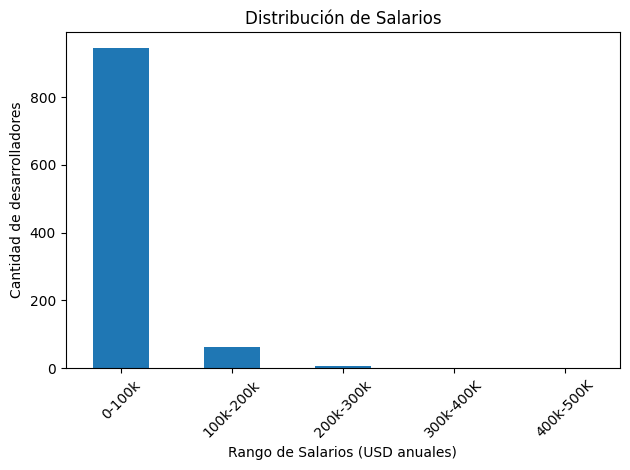

In [23]:
salary_dist.plot(kind='bar')
plt.title('Distribución de Salarios')
plt.xlabel('Rango de Salarios (USD anuales)')
plt.ylabel('Cantidad de desarrolladores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusion

The salary distribution shows a clear concentration below USD 100,000 per year. The high-salary segment (≥ USD 100,000) represents a small proportion of the total, while salaries above USD 200,000 appear to be marginal within the regional market.

### Derived Hypotheses

Given that approximately 6% of professionals fall within the USD 100,000–200,000 range, it becomes relevant to explore which factors may explain this difference:

* Does the work modality (remote vs. on-site) influence access to higher salaries?
* Is there a significant relationship between professional experience and salary level?
* Does regional geography play a role in these differences?


### Analysis 2 — Professional Experience and Salary Level

**Hypothesis**

Professionals with more years of experience are more likely to earn salaries above USD 100,000 per year.


In [24]:
#Ahora crucemos esto con experiencia
df_latam_clean.groupby('HighSalary')['YearsCodePro'].median()

,YearsCodePro
HighSalary,
False,7
True,14


In [25]:
#Aca agrupamos por salario y experiencia
df_latam_clean.groupby('HighSalary')['YearsCodePro'].mean()

,YearsCodePro
HighSalary,
False,9
True,14


In [26]:
exp_median = (
    df_latam_clean.groupby('HighSalary')['YearsCodePro'].median()
)

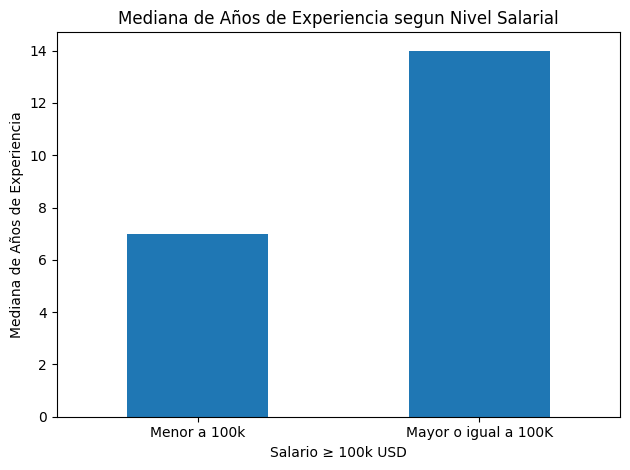

In [27]:
exp_median.plot(kind='bar')

plt.title('Mediana de Años de Experiencia segun Nivel Salarial')
plt.xlabel('Salario ≥ 100k USD')
plt.ylabel('Mediana de Años de Experiencia')
plt.xticks([0,1],['Menor a 100k', 'Mayor o igual a 100K'],rotation=0)
plt.tight_layout()
plt.show()

### Conclusion

The group earning ≥ USD 100,000 shows a significantly higher mean level of professional experience compared to the group earning < USD 100,000.

However, the fact that the lower-income group records an average close to nine years of experience indicates that professional experience, while relevant, is not sufficient on its own to access the higher salary segment.

This suggests that additional variables influence access to higher income levels within the Latin American technology market.


# Analysis 3 — Professional Role and Salary Level

**Hypothesis**

Salary levels may depend not only on professional experience, but also on the specific role performed by the professional.


In [28]:
#Ver cuantas categorias distintas exiaten
df_latam_clean['DevType'].nunique()

31

In [29]:
#La lista completa
df_latam_clean['DevType'].value_counts()

,count
DevType,
"Developer, full-stack",420
"Developer, back-end",221
"Developer, front-end",58
"Developer, desktop or enterprise applications",35
Data engineer,34
"Developer, mobile",31
Engineering manager,22
Other (please specify):,21
DevOps specialist,19


In [30]:
df_latam_clean.groupby('DevType')['ConvertedCompYearly'].median().sort_values(ascending=False)

,ConvertedCompYearly
DevType,
Developer Advocate,"80,000"
Engineering manager,"60,608"
Security professional,"58,277"
Cloud infrastructure engineer,"52,992"
"Senior Executive (C-Suite, VP, etc.)","47,716"
"Engineer, site reliability","45,223"
"Developer, AI","40,095"
Project manager,"39,220"
"Developer, embedded applications or devices","37,992"


In [31]:
#Se eliminan los roles que no tienen una cantidad de datos relevantes
role_counts = df_latam_clean['DevType'].value_counts()
valid_counts = role_counts[role_counts>=10].index
df_latam_clean = df_latam_clean[df_latam_clean['DevType'].isin(valid_counts)]
df_latam_clean['DevType'].value_counts()

,count
DevType,
"Developer, full-stack",420
"Developer, back-end",221
"Developer, front-end",58
"Developer, desktop or enterprise applications",35
Data engineer,34
"Developer, mobile",31
Engineering manager,22
Other (please specify):,21
DevOps specialist,19


In [32]:
df_latam_clean.groupby('DevType')['ConvertedCompYearly'].min().sort_values(ascending=False)

,ConvertedCompYearly
DevType,
Data or business analyst,"8,327"
Research & Development role,"8,314"
"Developer, embedded applications or devices","5,576"
Engineering manager,"5,543"
Data engineer,"4,476"
"Developer, mobile","4,009"
"Senior Executive (C-Suite, VP, etc.)","3,730"
"Developer, desktop or enterprise applications","3,357"
"Engineer, site reliability","3,326"


In [33]:
df_latam_clean.groupby('DevType')['ConvertedCompYearly'].max().sort_values(ascending=False)

,ConvertedCompYearly
DevType,
"Developer, full-stack","500,000"
"Developer, back-end","250,000"
Engineering manager,"242,433"
"Developer, front-end","211,336"
DevOps specialist,"145,000"
Other (please specify):,"137,000"
"Developer, embedded applications or devices","130,541"
"Senior Executive (C-Suite, VP, etc.)","130,541"
"Developer, mobile","120,379"


### Methodological Consideration

Due to the presence of extreme outliers in the salary data, the **median** is used as the main measure of central tendency instead of the mean. The median is more robust to outliers and provides a more accurate representation of the salary distribution.

Some extremely low salary values (for example, values close to 5 or 14 USD per year) are likely due to data entry errors, differences in how respondents interpreted the question, or responses that do not accurately reflect the labor market.


#

#Hypothesis 2

Does salary depend on the professional role, on experience, or on both factors?

In [34]:
df_latam_clean = df_latam_clean[df_latam_clean['ConvertedCompYearly']>=1000]

In [35]:
salary_by_roles = (
    df_latam_clean.groupby('DevType')['ConvertedCompYearly'].median()
)

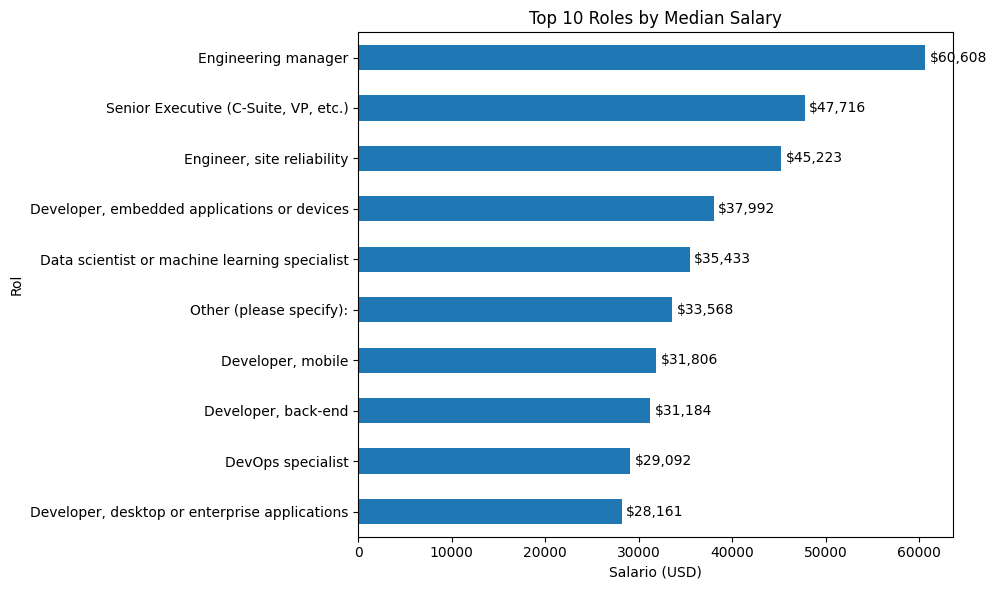

In [36]:
top_roles = salary_by_roles.sort_values().tail(10)

plt.figure(figsize=(10,6))
ax = top_roles.plot(kind='barh')

plt.title('Top 10 Roles by Median Salary')
plt.xlabel('Salario (USD)')
plt.ylabel('Rol')

for i, v in enumerate(top_roles):
    ax.text(v + 500, i, f"${v:,.0f}", va='center')

plt.tight_layout()
plt.show()

The results show that leadership and infrastructure-related roles tend to have higher median salaries compared to other technical positions.

In [37]:
exp_by_role = df_latam_clean.groupby('DevType')['YearsCodePro'].median().sort_values(ascending=False)
exp_by_role

,YearsCodePro
DevType,
"Senior Executive (C-Suite, VP, etc.)",14
Engineering manager,12
DevOps specialist,12
"Engineer, site reliability",12
Research & Development role,10
"Developer, desktop or enterprise applications",10
"Developer, embedded applications or devices",9
Other (please specify):,8
"Developer, front-end",7


In [38]:
role_analysis = df_latam_clean.groupby('DevType').agg({
    'YearsCodePro':'median',
    'ConvertedCompYearly':'median'
}).sort_values(by='YearsCodePro', ascending=False)
role_analysis

,YearsCodePro,ConvertedCompYearly
DevType,,
"Senior Executive (C-Suite, VP, etc.)",14,"47,716"
Engineering manager,12,"60,608"
DevOps specialist,12,"29,092"
"Engineer, site reliability",12,"45,223"
Research & Development role,10,"25,996"
"Developer, desktop or enterprise applications",10,"28,161"
"Developer, embedded applications or devices",9,"37,992"
Other (please specify):,8,"33,568"
"Developer, front-end",7,"27,888"


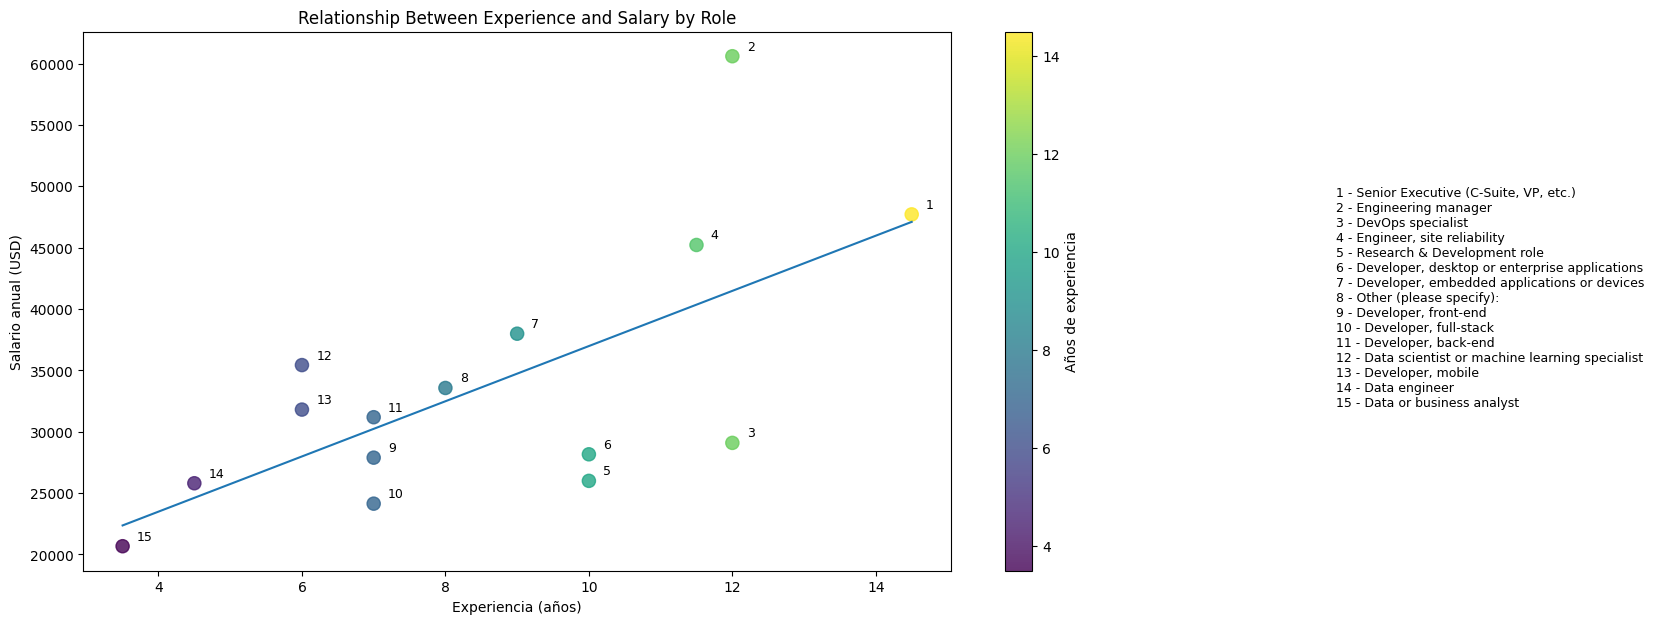

In [39]:
plt.figure(figsize=(14,7))

x = role_analysis['YearsCodePro']
y = role_analysis['ConvertedCompYearly']

scatter = plt.scatter(x, y, s=90, c=x, cmap='viridis', alpha=0.8)

plt.colorbar(scatter, label='Años de experiencia')

# numerar puntos
for i, (role, row) in enumerate(role_analysis.iterrows(), start=1):
    plt.text(row['YearsCodePro']+0.2,
             row['ConvertedCompYearly']+500,
             str(i),
             fontsize=9)

# línea de tendencia
m, b = np.polyfit(x, y, 1)
sorted_x = np.sort(x)
plt.plot(sorted_x, m*sorted_x + b)

plt.title('Relationship Between Experience and Salary by Role')
plt.xlabel('Experiencia (años)')
plt.ylabel('Salario anual (USD)')

# lista de roles
roles_text = "\n".join(
    [f"{i+1} - {role}" for i, role in enumerate(role_analysis.index)]
)

plt.figtext(1.02, 0.5, roles_text, fontsize=9, va="center")

plt.show()

# Conclusion

The analysis shows a positive relationship between professional experience and salary level, as roles with a higher average number of years of experience tend to exhibit higher salaries.

However, experience alone does not fully explain salary differences. The professional role also has a significant impact on compensation.

This can be observed when comparing roles with similar levels of experience but very different salary levels. For example, a Hardware Engineer with approximately 15 years of experience has a median salary close to USD 18,000, while a Product Manager with a similar level of experience reaches approximately USD 37,000.

Additionally, differences can be observed within development roles among professionals with comparable experience. For instance, full-stack, front-end, and back-end developers show an average of around seven years of experience but display notable differences in their salary levels.

Overall, these results suggest that both professional experience and role specialization influence salary levels. However, the specific role performed can generate significant salary differences even among professionals with similar career trajectories.


# Analysis 4 — Work Modality and High Salaries

*Hypothesis*

Remote work may increase the likelihood of earning salaries ≥ USD 100,000 per year.

In [41]:
pd.reset_option('display.float_format')

In [42]:
#¿Ser remoto  aumenta la probabilidad?

df_latam_clean.groupby('RemoteWork')['HighSalary'].mean().sort_values(ascending=False)

,HighSalary
RemoteWork,
Remote,0.105169
In-person,0.023438
"Hybrid (some remote, some in-person)",0.017937


#Results
The probability of earning a salary ≥ USD 100,000 is considerably higher among remote workers (≈10%) compared to hybrid or on-site work arrangements (≈2%).

This pattern may reflect the fact that remote positions often provide access to international job markets and companies with higher salary structures.

In [43]:
#Los que ganan mucho, ¿qué modalidad tienen?
df_latam_clean[df_latam_clean['HighSalary']==True]['RemoteWork'].value_counts(normalize=True)

,proportion
RemoteWork,
Remote,0.893939
"Hybrid (some remote, some in-person)",0.060606
In-person,0.045455


#Findings

Among professionals earning salaries ≥ USD 100,000, the vast majority work remotely (≈89%), while only a small proportion work in hybrid (≈6%) or on-site roles (≈4%).

These results reinforce the previous findings, suggesting that high salaries in the Latin American technology market are strongly associated with remote work arrangements.


In [44]:
remote_salary = (
    df_latam_clean.groupby('RemoteWork')['HighSalary'].mean().sort_values(ascending=False)
)

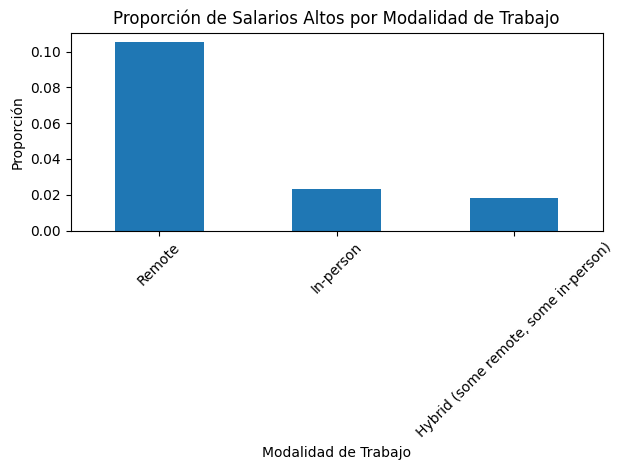

In [45]:
remote_salary.plot(kind='bar')
plt.title('Proporción de Salarios Altos por Modalidad de Trabajo')
plt.xlabel('Modalidad de Trabajo')
plt.ylabel('Proporción')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Conclusion

Professional experience shows a positive relationship with salary level. However, remote work exhibits a significantly stronger association with access to high salaries, suggesting that access to international job markets may be a key factor in the salary structure of the Latin American technology sector.


# Analysis 5 — Country Influence on Salary Levels

*Objective*

To evaluate whether the developer's country of origin influences the probability of reaching salaries above USD 100,000 per year within the Latin American technology market.

To address this question, the following aspects will be analyzed:

* The proportion of salaries ≥ USD 100,000 by country
* The average level of professional experience in each country

This analysis will help identify whether regional differences exist within the Latin American technology labor market.


In [48]:
#Probabilidad de salario alto por pais
pd.reset_option('display.float_format')
df_latam_clean.groupby('Country')['HighSalary'].mean().sort_values(ascending=False)

,HighSalary
Country,
Argentina,0.148936
Uruguay,0.148148
Mexico,0.067164
Brazil,0.065574
Colombia,0.042254
Chile,0.000000


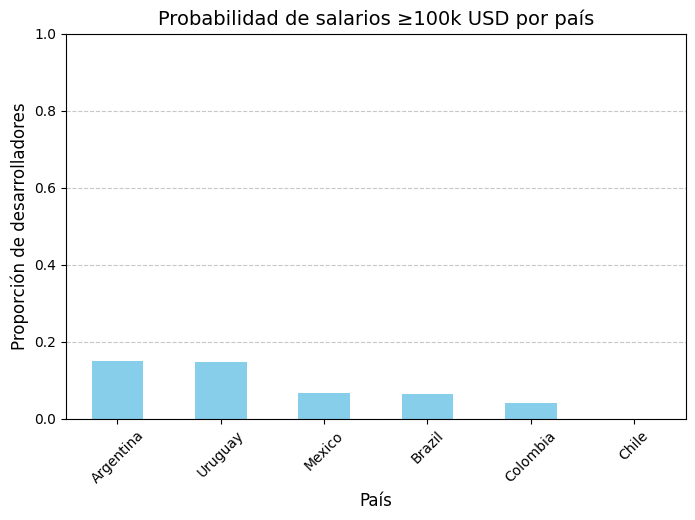

In [47]:
# Probabilidad de HighSalary por país
prob_high_salary = df_latam_clean.groupby('Country')['HighSalary'].mean().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(8,5))
prob_high_salary.plot(kind='bar', color='skyblue')
plt.title('Probabilidad de salarios ≥100k USD por país', fontsize=14)
plt.ylabel('Proporción de desarrolladores', fontsize=12)
plt.xlabel('País', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Results

The proportion of developers earning salaries ≥ USD 100,000 was analyzed for each Latin American country. Argentina and Uruguay show the highest relative proportion of high salaries (14.9% and 14.8%, respectively), while Brazil and Mexico present values close to 6%.

These results suggest that regional differences exist within the Latin American technology market, although the proportion of high salaries remains relatively small across all countries.


In [49]:
#Experiencia promedio por país
from pandas.core import groupby
df_latam_clean[df_latam_clean['HighSalary']== True].groupby('Country')['YearsCodePro'].median().sort_values(ascending=False)

,YearsCodePro
Country,
Uruguay,17.5
Argentina,16.0
Brazil,12.0
Mexico,11.0
Colombia,9.0


In [50]:

df_latam_clean[df_latam_clean['HighSalary']== False].groupby('Country')['YearsCodePro'].min().sort_values(ascending=False)


,YearsCodePro
Country,
Chile,1.0
Argentina,0.0
Brazil,0.0
Colombia,0.0
Mexico,0.0
Uruguay,0.0


### Observation

During the analysis, an isolated case was identified in Chile where a developer with approximately one year of professional experience reported an annual salary above USD 100,000.

However, this result corresponds to a single record within the dataset and therefore does not allow conclusions to be drawn about a real trend in the market.

Such cases may be related to variables not included in this analysis (for example: role type, international companies, technical specialization, or remote work). Therefore, it is considered an interesting anomaly but not a conclusive finding.


# Conclusion

The average years of professional experience also show differences across countries. Uruguay and Argentina present the highest values (17 and 16 years respectively), while Colombia shows the lowest average (9 years).

This pattern may reflect differences in market maturity or in the composition of the survey sample.


# Final Conclusion

The analysis of the technology labor market in Latin America shows that the vast majority of salaries are concentrated below USD 100,000 annually.

Although professional experience is associated with higher salaries, it does not appear to be the only determining factor.

The results indicate that remote work has a significant relationship with salaries above USD 100,000. In this sample, the vast majority of developers who reach these salary levels work remotely.

This suggests that access to international job markets may be a key factor in achieving the highest salary levels within the technology sector in the region.


## Insights

The results suggest that access to international job markets may be one of the most important factors for achieving high salaries in the Latin American technology sector.

A first key insight from the analysis is that the Latin American technology labor market shows a strong concentration of salaries below USD 100,000 annually. High salaries represent only a small proportion of the total sample, suggesting that reaching this salary level is relatively uncommon within the regional market.

The strong relationship between remote work and salaries ≥ USD 100,000 indicates that many Latin American developers may be participating in global labor markets rather than being limited to local salary structures.

Additionally, salary levels appear to depend on a combination of professional experience and role specialization. Developers with more experience tend to earn higher salaries, but the professional role also plays a significant role in determining compensation levels.

These findings raise further questions about how international companies select talent in the region and which factors influence access to global opportunities.
